In [231]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Постановка задачи

Работаем с проверкой гипотез 5-9, cогласно с общей таблицей:

5) Анализ оценок по годам
6) Анализ оценок длительности
7) Анализ оценок по типу
8) Анализ оценок по бюджету
9) Анализ оценок по актерам

**Ключевые поля, которые будем сравнивать в зависимости от срезу или параметра:**
- *rating* - оценка пользователей в Кинопоиск
- vote_average_tmdb (иногда будем прибегать к popularity_tmdb) - оценка пользователей в TMDB

# Получение данных

In [232]:
df = pd.read_excel('total_df.xlsx')
df.head(3)

,Unnamed: 0,level_0,russian_title,english_title_kinopoisk,rating,vote_count_kinopoisk,genre,director,is_film,start_year,...,genre_tmdb_2,genre_tmdb_3,genre_tmdb_4,genre_tmdb_5,budget_tmdb,revenue_tmdb,company_creater_tmdb,buy_tmdb,rent_tmdb,keywords_tmdb
0,0,0,1+1,Intouchables,8.9,2791000.0,драма,Оливье Накаш,1.0,2011.0,...,35.0,NaN,NaN,NaN,13000000.0,426590315.0,NaN,[],[],NaN
1,1,1,Джентльмены,The Gentlemen,8.7,2473000.0,криминал,Гай Ричи,1.0,2019.0,...,80.0,NaN,NaN,NaN,22000000.0,115171795.0,NaN,"['Apple TV Store', 'Google Play Movies']","['Apple TV Store', 'Google Play Movies']",NaN
2,2,3,Гнев человеческий,Wrath of Man,7.7,1751000.0,боевик,Гай Ричи,1.0,2021.0,...,80.0,18.0,NaN,NaN,40000000.0,103966489.0,NaN,"['Apple TV Store', 'Google Play Movies', 'Kino...","['Apple TV Store', 'Google Play Movies']",NaN


In [233]:
df.columns

Index(['Unnamed: 0', 'level_0', 'russian_title', 'english_title_kinopoisk',
       'rating', 'vote_count_kinopoisk', 'genre', 'director', 'is_film',
       'start_year', 'end_year', 'duration_minutes', 'country', 'actors',
       'english_title_tmdb', 'id_tmdb', 'overview_tmdb', 'release_date',
       'genre_ids_tmdb', 'popularity_tmdb', 'vote_average_tmdb',
       'vote_count_tmdb', 'genre_tmdb_1', 'genre_tmdb_2', 'genre_tmdb_3',
       'genre_tmdb_4', 'genre_tmdb_5', 'budget_tmdb', 'revenue_tmdb',
       'company_creater_tmdb', 'buy_tmdb', 'rent_tmdb', 'keywords_tmdb'],
      dtype='object')

In [234]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41367 entries, 0 to 41366
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               41367 non-null  int64  
 1   level_0                  41367 non-null  int64  
 2   russian_title            41367 non-null  object 
 3   english_title_kinopoisk  40806 non-null  object 
 4   rating                   38968 non-null  float64
 5   vote_count_kinopoisk     38968 non-null  float64
 6   genre                    41355 non-null  object 
 7   director                 40890 non-null  object 
 8   is_film                  41159 non-null  float64
 9   start_year               35379 non-null  float64
 10  end_year                 5024 non-null   float64
 11  duration_minutes         30355 non-null  float64
 12  country                  41363 non-null  object 
 13  actors                   41363 non-null  object 
 14  english_title_tmdb    

# Обработка данных и feature engineering 

Удалим лишние столбцы

In [235]:
print(f'Размер до удаления столбцов {df.shape}')

df.drop(['Unnamed: 0', 'level_0'], axis=1, inplace=True)

print(f'Размер после удаления столбцов {df.shape}')

Размер до удаления столбцов (41367, 33)
Размер после удаления столбцов (41367, 31)


## Анализ оценок по годам

In [236]:
df.columns

len_df = len(df)

In [237]:
year_analysis = df[['start_year', 'rating', 'vote_average_tmdb']]
year_analysis

,start_year,rating,vote_average_tmdb
0,2011.0,8.9,8.269
1,2019.0,8.7,7.662
2,2021.0,7.7,7.600
3,2013.0,8.1,8.028
4,2011.0,9.0,7.100
...,...,...,...
41362,2025.0,6.1,7.200
41363,2023.0,5.8,5.700
41364,2022.0,7.1,5.100
41365,2023.0,5.8,5.500


In [238]:
for item in year_analysis.columns:
    print(np.round(year_analysis[item].isna().sum() / len_df, 2))

0.14
0.06
0.24


Возьмем только данные без пропусков

In [239]:
year_analysis = year_analysis.dropna()

In [240]:
for item in year_analysis.columns:
    print(np.round(year_analysis[item].isna().sum() / len_df, 2))

0.0
0.0
0.0


Проанализируем значения показателей через среднее значение

In [241]:
year_svod = year_analysis.groupby('start_year').agg(
    kinopoisk_rating = ('rating', 'mean'),
    tmdb_rating = ('vote_average_tmdb', 'mean'),
    count_values = ('vote_average_tmdb', 'count'),
).reset_index()

In [242]:
year_svod

,start_year,kinopoisk_rating,tmdb_rating,count_values
0,1890.0,5.200000,7.000000,1
1,1892.0,3.900000,7.201000,1
2,1894.0,5.200000,4.800000,1
3,1895.0,7.350000,6.531000,2
4,1896.0,6.200000,5.661500,4
...,...,...,...,...
125,2022.0,6.292398,5.871783,1026
126,2023.0,6.347510,5.874328,964
127,2024.0,6.268433,5.934089,868
128,2025.0,6.306033,5.884958,547


### Построим визуализации на основе группировки

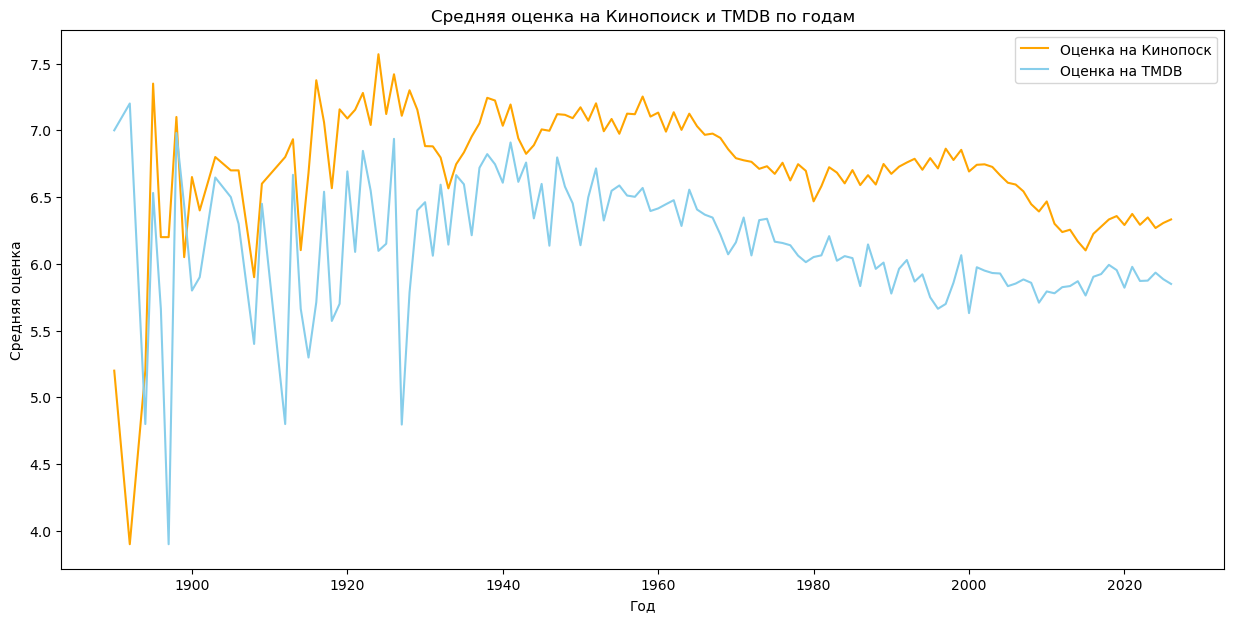

In [243]:
fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(
    year_svod['start_year'],
    year_svod['kinopoisk_rating'],
    label = 'Оценка на Кинопоск',
    color = 'orange'
)

ax.plot(
    year_svod['start_year'],
    year_svod['tmdb_rating'],
    label = 'Оценка на TMDB',
    color = 'skyblue'
)

ax.set_title('Средняя оценка на Кинопоиск и TMDB по годам')
ax.set_xlabel('Год')
ax.set_ylabel('Средняя оценка')

ax.legend()
plt.show()

Обрежем данные - будем брать после 1980 для детального анализа

In [244]:
year_svod_1980 = year_svod[year_svod['start_year'] >= 1980]

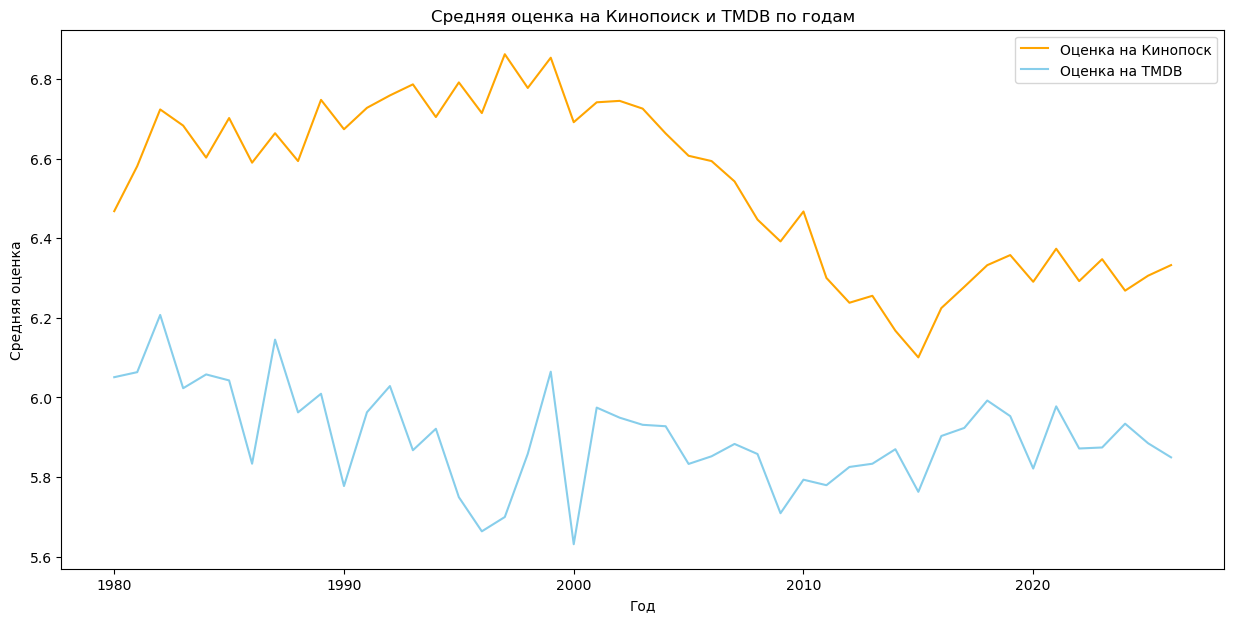

In [245]:
fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(
    year_svod_1980['start_year'],
    year_svod_1980['kinopoisk_rating'],
    label = 'Оценка на Кинопоск',
    color = 'orange'
)

ax.plot(
    year_svod_1980['start_year'],
    year_svod_1980['tmdb_rating'],
    label = 'Оценка на TMDB',
    color = 'skyblue'
)

ax.set_title('Средняя оценка на Кинопоиск и TMDB по годам')
ax.set_xlabel('Год')
ax.set_ylabel('Средняя оценка')

ax.legend()
plt.show()

## Кол-во фильмов по годам

In [246]:
year_svod['start_year'] = year_svod['start_year'].astype(int)

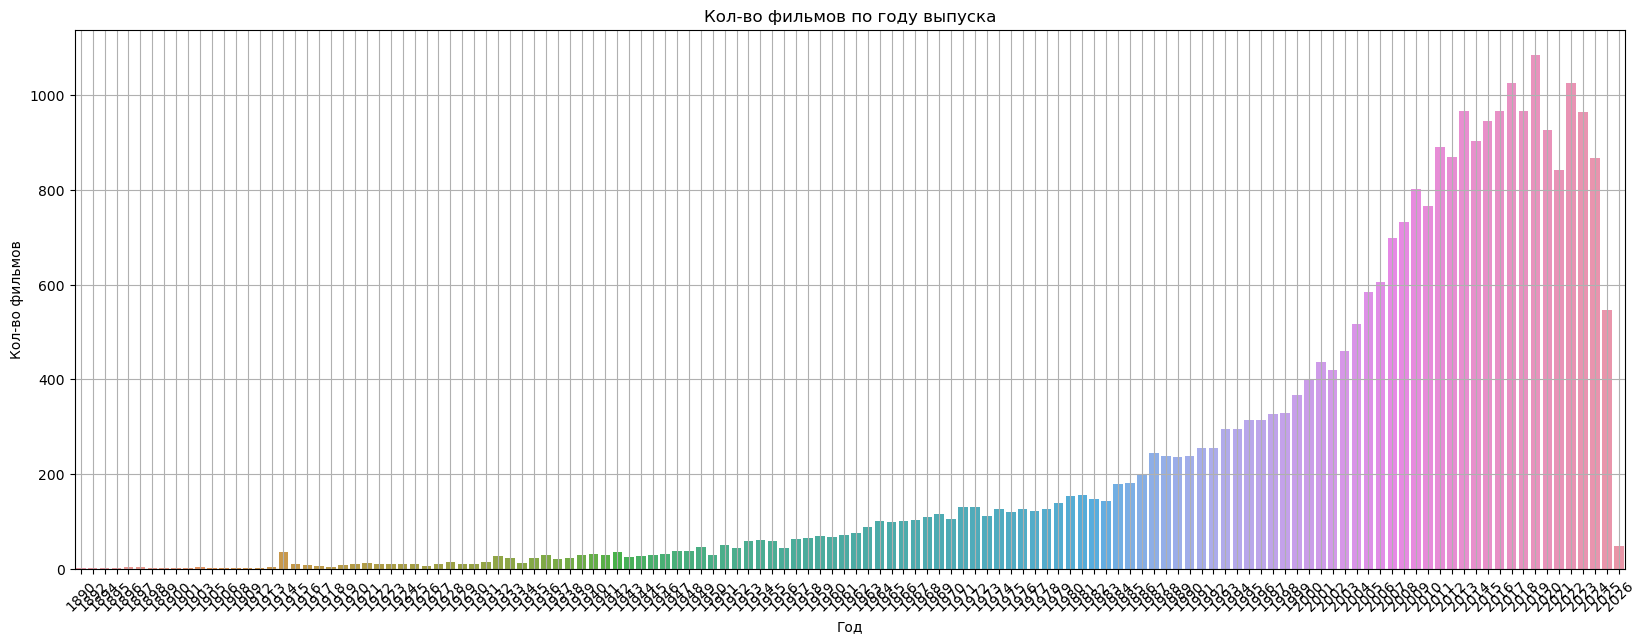

In [247]:
fig, ax = plt.subplots(figsize=(20, 7))

sns.barplot(
    data = year_svod,
    x = 'start_year',
    y = 'count_values'
)

ax.set_title('Кол-во фильмов по году выпуска')
ax.set_xlabel('Год')
ax.set_ylabel('Кол-во фильмов')

ax.grid()

plt.xticks(rotation=45)

plt.show()

## Анализ оценок и длительности

In [248]:
screen_time = df[['duration_minutes', 'rating', 'vote_average_tmdb']]
screen_time

,duration_minutes,rating,vote_average_tmdb
0,112.0,8.9,8.269
1,113.0,8.7,7.662
2,119.0,7.7,7.600
3,180.0,8.1,8.028
4,NaN,9.0,7.100
...,...,...,...
41362,104.0,6.1,7.200
41363,119.0,5.8,5.700
41364,NaN,7.1,5.100
41365,105.0,5.8,5.500


In [249]:
screen_time = screen_time.dropna()
screen_time.shape

(26921, 3)

Посмотрми на выбросы

In [250]:
print(len(screen_time[screen_time['duration_minutes'] < 10]))
print(len(screen_time[screen_time['duration_minutes'] < 15]))
print(len(screen_time[screen_time['duration_minutes'] < 30]))
print(len(screen_time[screen_time['duration_minutes'] > 300]))

298
410
673
10


In [251]:
# print(f'до фильтрафии {screen_time.shape}')

# screen_time = screen_time[screen_time['duration_minutes'].between(10, 300)]

# print(f'после фильтрафии {screen_time.shape}')

Разделим на следующие категории для визуализации

1) до 30 минут
2) от 30 минут до 60 минут
3) от 60 минут до 90 минут
4) от 90 минут до 120 минут
5) от 120 минут до 150 минут
6) от 150 минут до 180 минут
7) от 180 минут


In [252]:
time_periods = [
    0,
    30,
    60,
    90,
    120,
    150,
    180,
    1000
]


labels = [
    'менее 30 минут',
    '30-60 минут',
    '60-90 минут',
    '90-120 минут',
    '120-150 минут',
    '150-180 минут',
    'более 180 минут'
]

Дополним датасет выделеными обозначениями

метод pd.cut()

ссылка: https://www.geeksforgeeks.org/python/pandas-cut-method-in-python/

In [253]:
screen_time['time_label'] = pd.cut(screen_time['duration_minutes'], bins=time_periods, labels=labels)
screen_time.head(10)

/var/folders/by/79crn8_s18g3gffy7r7hhb9c0000gn/T/ipykernel_50510/1352765743.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  screen_time['time_label'] = pd.cut(screen_time['duration_minutes'], bins=time_periods, labels=labels)


,duration_minutes,rating,vote_average_tmdb,time_label
0,112.0,8.9,8.269,90-120 минут
1,113.0,8.7,7.662,90-120 минут
2,119.0,7.7,7.600,90-120 минут
3,180.0,8.1,8.028,150-180 минут
5,130.0,8.2,7.840,120-150 минут
6,130.0,8.5,8.223,120-150 минут
7,138.0,8.6,8.199,120-150 минут
8,103.0,8.3,5.300,90-120 минут
9,139.0,8.7,8.439,120-150 минут
10,123.0,7.9,5.800,120-150 минут


## Ввзаимосвязь группы длительности и оценки на TMDB / Кинопоиск

/Users/anastasia/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/Users/anastasia/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


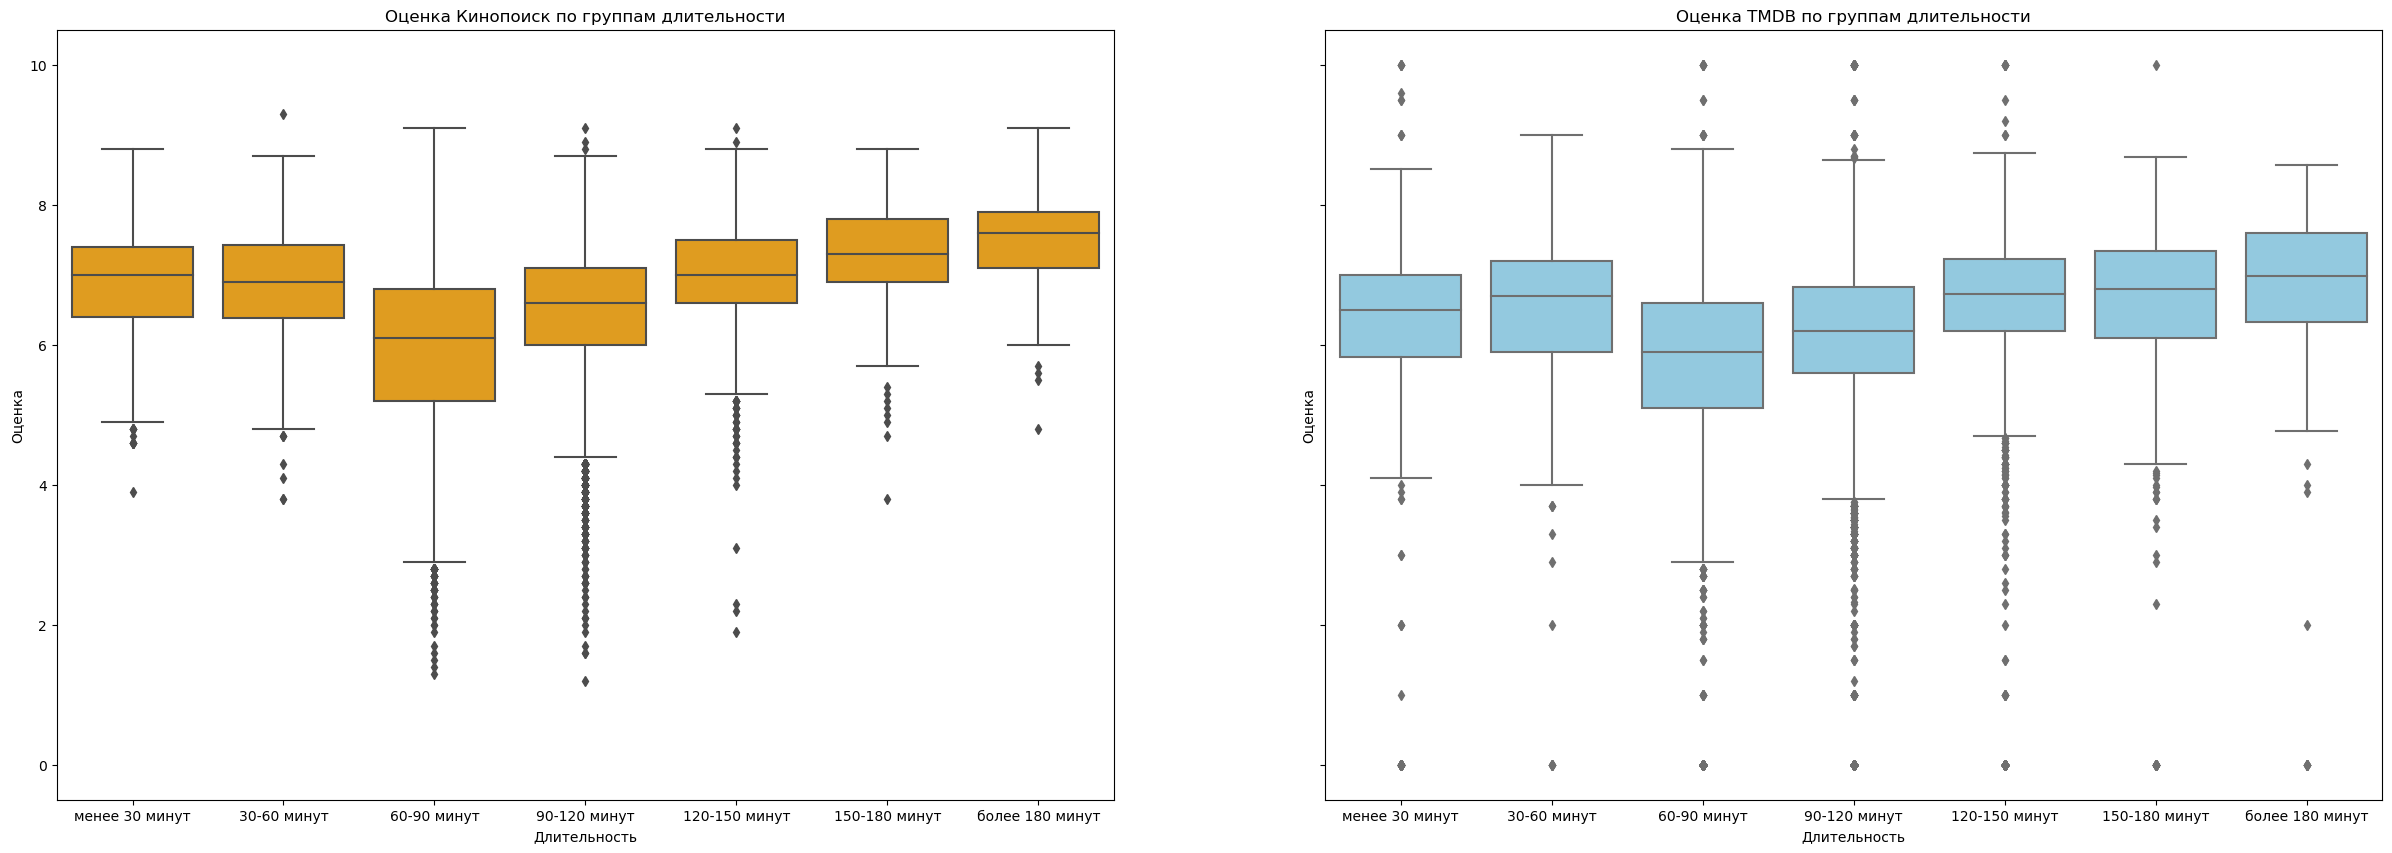

In [254]:
fig, ax = plt.subplots(1, 2, figsize=(30, 10), sharey=True)

sns.boxplot(
    data = screen_time,
    ax = ax[0],
    x = 'time_label',
    y = 'rating',
    color = 'orange'
)

sns.boxplot(
    data = screen_time,
    ax = ax[1],
    x = 'time_label',
    y = 'vote_average_tmdb',
    color = 'skyblue'
)

ax[0].set_title('Оценка Кинопоиск по группам длительности')
ax[1].set_title('Оценка TMDB по группам длительности')

ax[0].set_xlabel('Длительность')
ax[1].set_xlabel('Длительность')

ax[0].set_ylabel('Оценка')
ax[1].set_ylabel('Оценка')


plt.show()

## Распределение фильмов по длительности

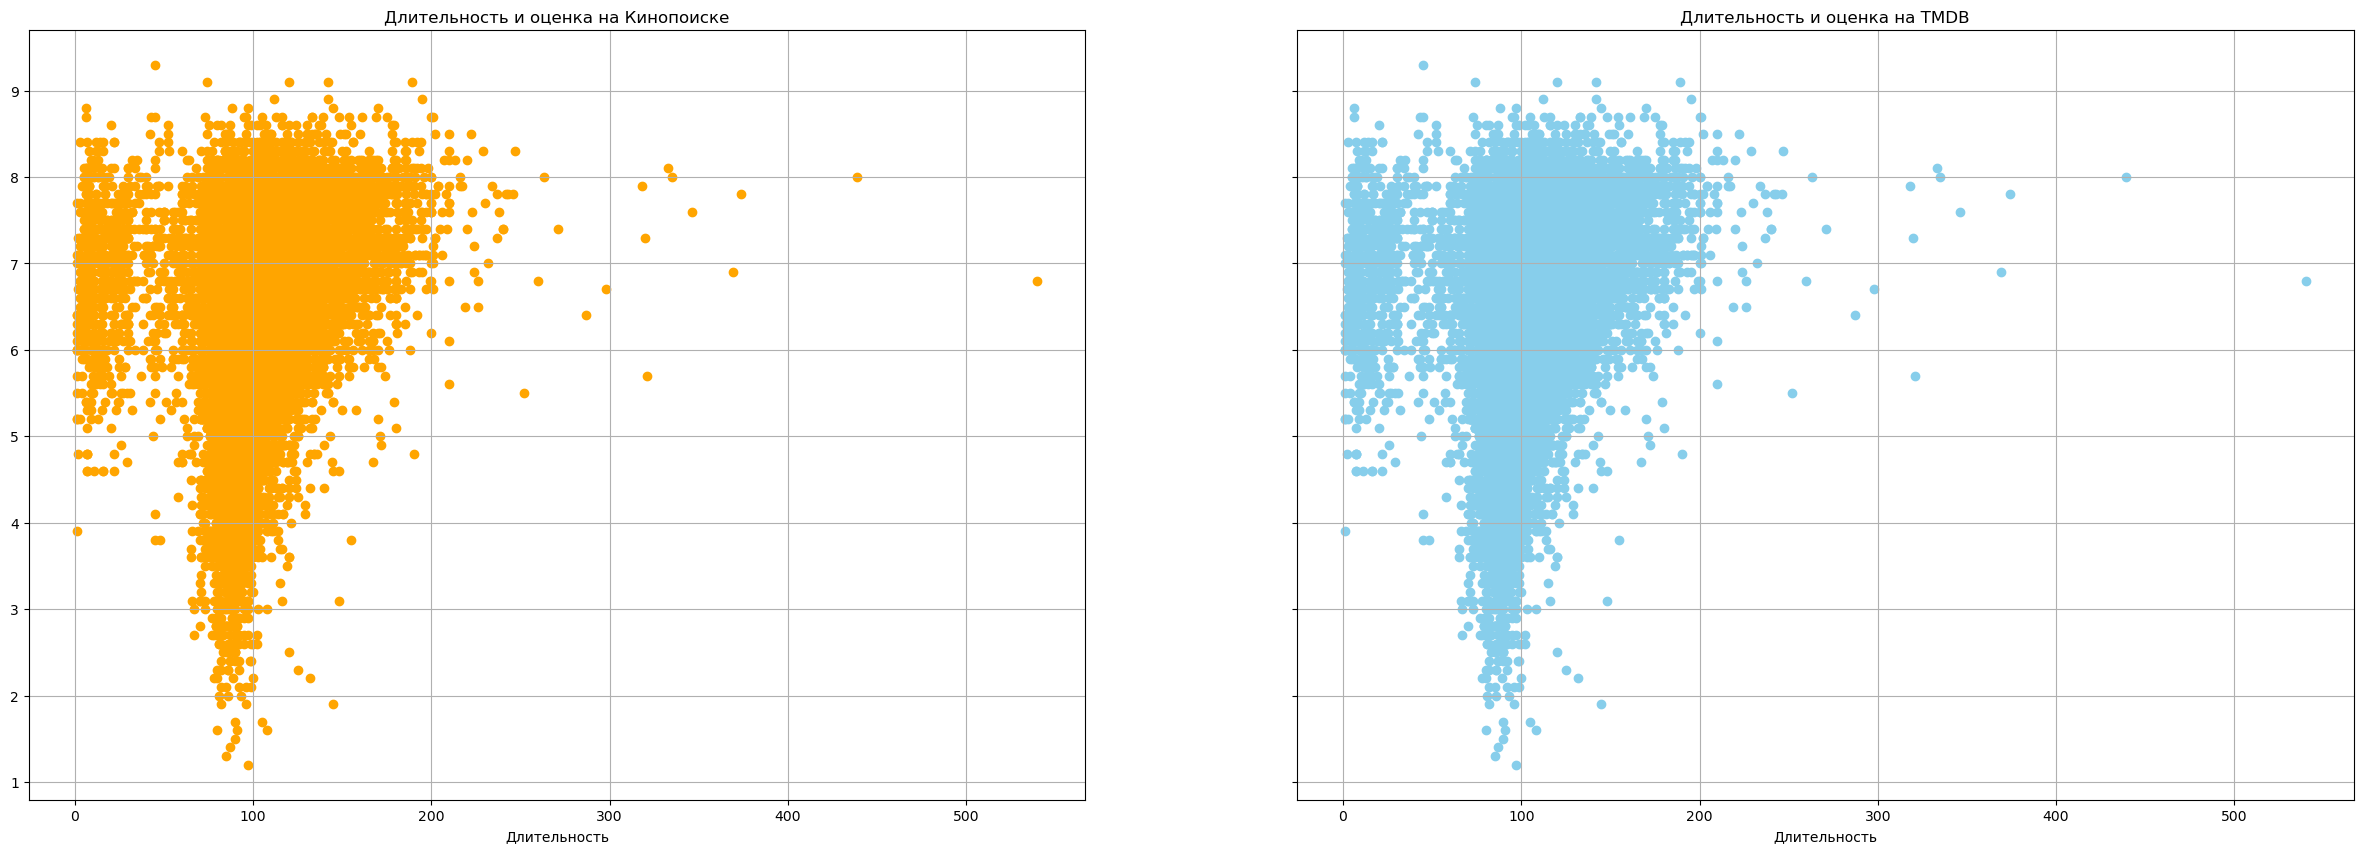

In [255]:
fig, ax = plt.subplots(1, 2, figsize=(30, 10), sharey=True)

ax[0].scatter(
    screen_time['duration_minutes'],
    screen_time['rating'],
    color='orange'
)

ax[1].scatter(
    screen_time['duration_minutes'],
    screen_time['rating'],
    color='skyblue'
)

ax[0].set_title('Длительность и оценка на Кинопоиске')
ax[1].set_title('Длительность и оценка на TMDB')

ax[0].set_xlabel('Длительность')
ax[1].set_xlabel('Длительность')

ax[0].grid()
ax[1].grid()

## Кол-во фильмов определенной длительности

In [256]:
to_hist = screen_time['time_label'].value_counts().sort_index()
to_hist

time_label
менее 30 минут       697
30-60 минут          236
60-90 минут         6388
90-120 минут       15742
120-150 минут       3064
150-180 минут        600
более 180 минут      194
Name: count, dtype: int64

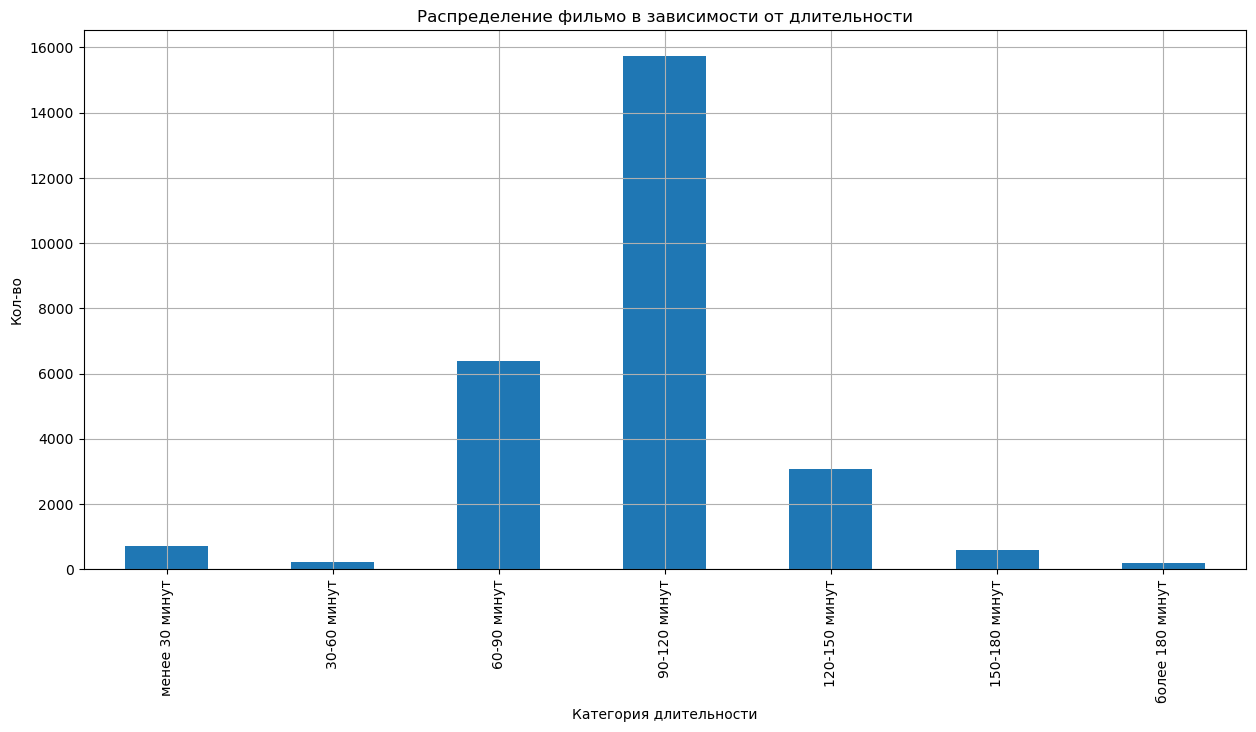

In [257]:
to_hist.plot(
    kind = 'bar',
    figsize = (15, 7)
)

plt.title('Распределение фильмо в зависимости от длительности')
plt.xlabel('Категория длительности')
plt.ylabel('Кол-во')

plt.grid()
plt.show()

## Анализ фильмов по типу

In [258]:
type_df = df[['is_film', 'rating', 'vote_average_tmdb']]
type_df

,is_film,rating,vote_average_tmdb
0,1.0,8.9,8.269
1,1.0,8.7,7.662
2,1.0,7.7,7.600
3,1.0,8.1,8.028
4,0.0,9.0,7.100
...,...,...,...
41362,1.0,6.1,7.200
41363,1.0,5.8,5.700
41364,0.0,7.1,5.100
41365,1.0,5.8,5.500


In [259]:
type_df['is_film'].isna().sum()

208

In [260]:
type_df = type_df.dropna(subset=['is_film'])
type_df['is_film'].isna().sum()

0

In [261]:
amount_of_films = len(type_df[type_df['is_film'] == True])
amount_of_serials = len(type_df[type_df['is_film'] == False])

print(amount_of_films, amount_of_serials)

30355 10804


## Базовое распределение - круговая диаграмма с %

Используем plt.pie

Ссылка на документацию: https://www.geeksforgeeks.org/python/plot-a-pie-chart-in-python-using-matplotlib/

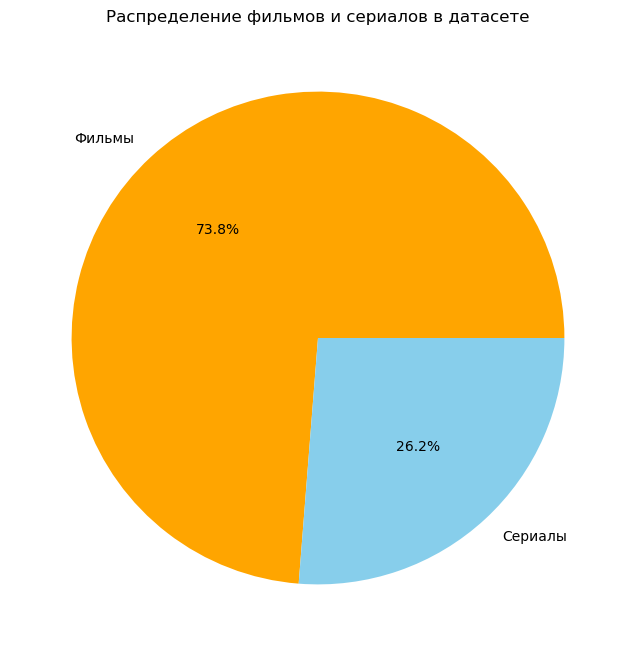

In [262]:
fig, ax = plt.subplots(figsize=(10, 8))

plt.pie(
    [amount_of_films, amount_of_serials],
    labels=['Фильмы', 'Сериалы'],
    colors=['orange', 'skyblue'],
    autopct='%1.1f%%'
)


plt.title('Распределение фильмов и сериалов в датасете')
plt.show()

In [263]:
type_svod = type_df.groupby('is_film').agg(
    kinopoisk_rating = ('rating', 'mean'),
    tmdb_rating = ('vote_average_tmdb', 'mean'),
    count_values = ('vote_average_tmdb', 'count'),
).reset_index()

type_svod

,is_film,kinopoisk_rating,tmdb_rating,count_values
0,0.0,7.163836,5.363685,3748
1,1.0,6.440094,5.936810,27528


In [264]:
type_df['is_film'] = type_df['is_film'].map({
    1: 'Фильм',
    0: 'Сериал'
})

/var/folders/by/79crn8_s18g3gffy7r7hhb9c0000gn/T/ipykernel_50510/2763712216.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  type_df['is_film'] = type_df['is_film'].map({


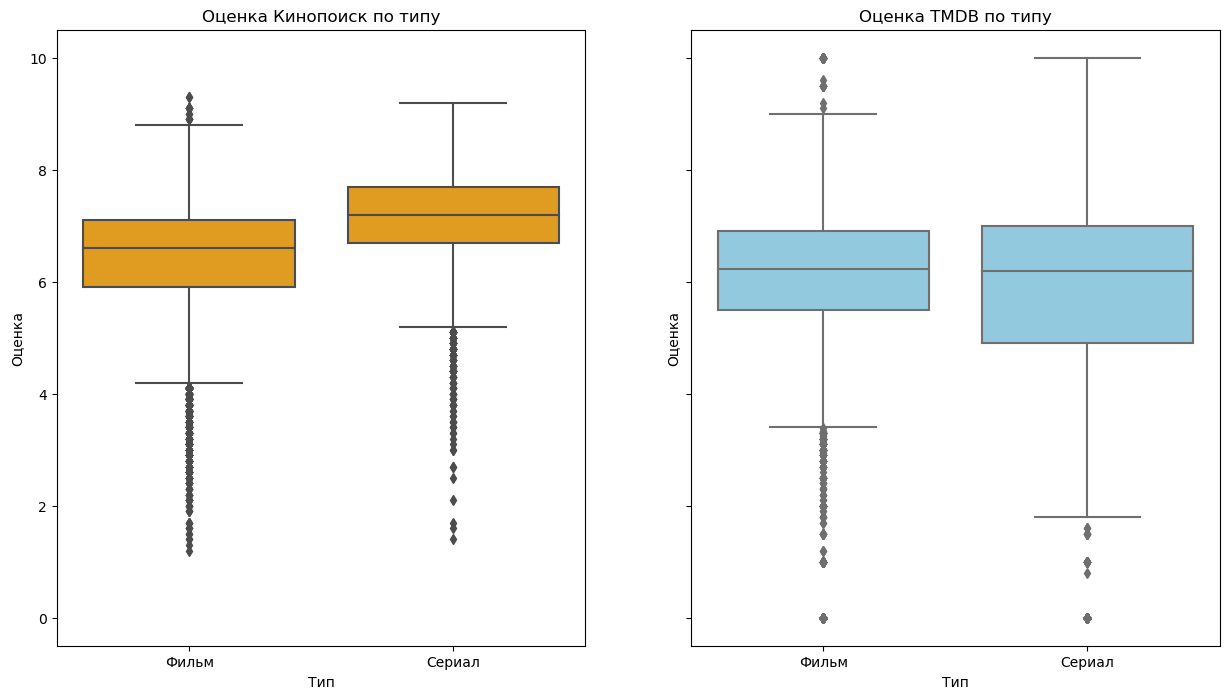

In [265]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8), sharey=True)


sns.boxplot(
    data = type_df,
    ax = ax[0],
    x = 'is_film',
    y = 'rating',
    color = 'orange'
)

sns.boxplot(
    data = type_df,
    ax = ax[1],
    x = 'is_film',
    y = 'vote_average_tmdb',
    color = 'skyblue'
)

ax[0].set_title('Оценка Кинопоиск по типу')
ax[1].set_title('Оценка TMDB по типу')

ax[0].set_xlabel('Тип')
ax[1].set_xlabel('Тип')

ax[0].set_ylabel('Оценка')
ax[1].set_ylabel('Оценка')


plt.show()

## Оценка по финансам

In [266]:
df.columns

Index(['russian_title', 'english_title_kinopoisk', 'rating',
       'vote_count_kinopoisk', 'genre', 'director', 'is_film', 'start_year',
       'end_year', 'duration_minutes', 'country', 'actors',
       'english_title_tmdb', 'id_tmdb', 'overview_tmdb', 'release_date',
       'genre_ids_tmdb', 'popularity_tmdb', 'vote_average_tmdb',
       'vote_count_tmdb', 'genre_tmdb_1', 'genre_tmdb_2', 'genre_tmdb_3',
       'genre_tmdb_4', 'genre_tmdb_5', 'budget_tmdb', 'revenue_tmdb',
       'company_creater_tmdb', 'buy_tmdb', 'rent_tmdb', 'keywords_tmdb'],
      dtype='object')

In [268]:
finance_df = df[['budget_tmdb', 'revenue_tmdb', 'rating', 'vote_average_tmdb']]
finance_df

,budget_tmdb,revenue_tmdb,rating,vote_average_tmdb
0,13000000.0,426590315.0,8.9,8.269
1,22000000.0,115171795.0,8.7,7.662
2,40000000.0,103966489.0,7.7,7.600
3,100000000.0,407038432.0,8.1,8.028
4,NaN,NaN,9.0,7.100
...,...,...,...,...
41362,NaN,NaN,6.1,7.200
41363,4000000.0,1261221.0,5.8,5.700
41364,NaN,NaN,7.1,5.100
41365,NaN,NaN,5.8,5.500


In [273]:
finance_df.dropna(subset=['budget_tmdb', 'revenue_tmdb', 'rating', 'vote_average_tmdb'], inplace=True)
finance_df

/var/folders/by/79crn8_s18g3gffy7r7hhb9c0000gn/T/ipykernel_50510/2697970257.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  finance_df.dropna(subset=['budget_tmdb', 'revenue_tmdb', 'rating', 'vote_average_tmdb'], inplace=True)


,budget_tmdb,revenue_tmdb,rating,vote_average_tmdb
0,13000000.0,426590315.0,8.9,8.269
1,22000000.0,115171795.0,8.7,7.662
2,40000000.0,103966489.0,7.7,7.600
3,100000000.0,407038432.0,8.1,8.028
5,40000000.0,312897920.0,8.2,7.840
...,...,...,...,...
41352,5500000.0,3500000.0,6.9,7.000
41354,30000000.0,14000000.0,5.5,5.097
41355,5000000.0,3074681.0,5.8,6.000
41359,165000000.0,746606706.0,5.8,8.470


In [274]:
for item in finance_df.columns:
    print(finance_df[item].isna().sum())

0
0
0
0


In [275]:
finance_df['return'] = finance_df['revenue_tmdb'] / finance_df['budget_tmdb']

/var/folders/by/79crn8_s18g3gffy7r7hhb9c0000gn/T/ipykernel_50510/4257705844.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  finance_df['return'] = finance_df['revenue_tmdb'] / finance_df['budget_tmdb']


In [278]:
finance_df

,budget_tmdb,revenue_tmdb,rating,vote_average_tmdb,return
0,13000000.0,426590315.0,8.9,8.269,32.814640
1,22000000.0,115171795.0,8.7,7.662,5.235082
2,40000000.0,103966489.0,7.7,7.600,2.599162
3,100000000.0,407038432.0,8.1,8.028,4.070384
5,40000000.0,312897920.0,8.2,7.840,7.822448
...,...,...,...,...,...
41352,5500000.0,3500000.0,6.9,7.000,0.636364
41354,30000000.0,14000000.0,5.5,5.097,0.466667
41355,5000000.0,3074681.0,5.8,6.000,0.614936
41359,165000000.0,746606706.0,5.8,8.470,4.524889


In [277]:
finance_df.to_excel('finance.xlsx')

Сделаем группировку по группе бюджетов со средними значениями.

Сначаал определим 5 уровней бюджета - по квантилям

Используем метод qcut, ссылка на документацию: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html

In [282]:
finance_df['budget_label'] = pd.qcut(
    finance_df['budget_tmdb'],
    q = 5,
    labels=['Низкий', 'Ниже среднего', 'Средний', 'Выше среднего', 'Высокий']
)

finance_df

/var/folders/by/79crn8_s18g3gffy7r7hhb9c0000gn/T/ipykernel_50510/2370316160.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  finance_df['budget_label'] = pd.qcut(


,budget_tmdb,revenue_tmdb,rating,vote_average_tmdb,return,bidget_label,budget_label
0,13000000.0,426590315.0,8.9,8.269,32.814640,Средний,Средний
1,22000000.0,115171795.0,8.7,7.662,5.235082,Средний,Средний
2,40000000.0,103966489.0,7.7,7.600,2.599162,Выше среднего,Выше среднего
3,100000000.0,407038432.0,8.1,8.028,4.070384,Высокий,Высокий
5,40000000.0,312897920.0,8.2,7.840,7.822448,Выше среднего,Выше среднего
...,...,...,...,...,...,...,...
41352,5500000.0,3500000.0,6.9,7.000,0.636364,Ниже среднего,Ниже среднего
41354,30000000.0,14000000.0,5.5,5.097,0.466667,Выше среднего,Выше среднего
41355,5000000.0,3074681.0,5.8,6.000,0.614936,Ниже среднего,Ниже среднего
41359,165000000.0,746606706.0,5.8,8.470,4.524889,Высокий,Высокий


In [284]:
finance_svod = finance_df.groupby('budget_label').agg(
    kinopoisk_rating = ('rating', 'mean'),
    tmdb_rating = ('vote_average_tmdb', 'mean'),
    count_values = ('vote_average_tmdb', 'count'),
    return_of_film = ('return', 'mean'),
).reset_index()

finance_svod

/var/folders/by/79crn8_s18g3gffy7r7hhb9c0000gn/T/ipykernel_50510/2701142275.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  finance_svod = finance_df.groupby('budget_label').agg(


,budget_label,kinopoisk_rating,tmdb_rating,count_values,return_of_film
0,Низкий,6.670926,6.576969,1847,1664.289013
1,Ниже среднего,6.646047,6.440614,1796,3.657288
2,Средний,6.683416,6.487762,1821,3.172734
3,Выше среднего,6.740390,6.465932,1847,2.526862
4,Высокий,6.813649,6.729809,1795,3.141247


/Users/anastasia/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/Users/anastasia/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


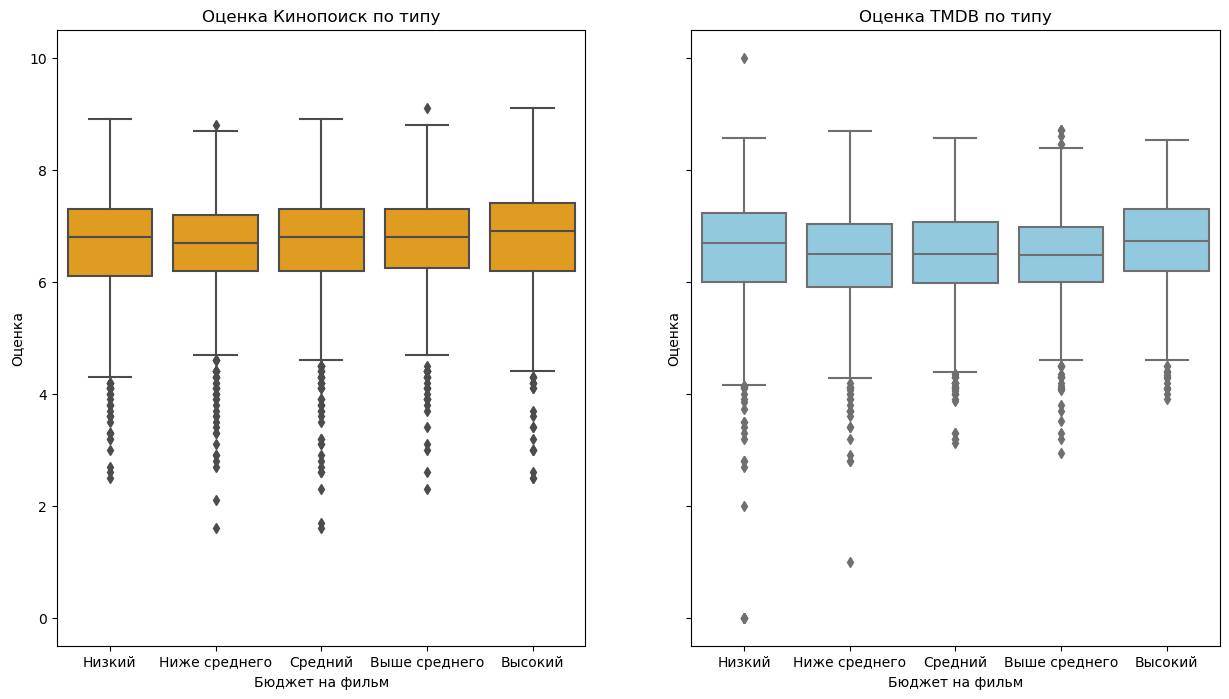

In [288]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8), sharey=True)


sns.boxplot(
    data = finance_df,
    ax = ax[0],
    x = 'budget_label',
    y = 'rating',
    color = 'orange'
)

sns.boxplot(
    data = finance_df,
    ax = ax[1],
    x = 'budget_label',
    y = 'vote_average_tmdb',
    color = 'skyblue'
)

ax[0].set_title('Оценка Кинопоиск по типу')
ax[1].set_title('Оценка TMDB по типу')

ax[0].set_xlabel('Бюджет на фильм')
ax[1].set_xlabel('Бюджет на фильм')

ax[0].set_ylabel('Оценка')
ax[1].set_ylabel('Оценка')


plt.show()

In [289]:
sep_len = range(len(finance_svod))

In [293]:
# 